In [2]:
# Install huggingface transformers for the accelerated vision-language model pipeline
!pip install -q transformers datasets accelerate nltk

import os
import zipfile
import urllib.request
import collections
import re
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [3]:
# --- 1. Environment & Data Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download Flickr8k safely via an open public mirror
DATA_URL = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
TEXT_URL = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

if not os.path.exists("Flickr8k_Dataset.zip"):
    print("Downloading images (approx 1GB)...")
    urllib.request.urlretrieve(DATA_URL, "Flickr8k_Dataset.zip")
if not os.path.exists("Flickr8k_text.zip"):
    print("Downloading captions...")
    urllib.request.urlretrieve(TEXT_URL, "Flickr8k_text.zip")

# Extract files
for zip_fn in ["Flickr8k_Dataset.zip", "Flickr8k_text.zip"]:
    with zipfile.ZipFile(zip_fn, 'r') as zip_ref:
        zip_ref.extractall(".")
print("Dataset extracted successfully.")

# --- 2. Precise Split Parsing (6000 Train, 1000 Val, 1000 Test) ---
def load_split_image_names(file_path):
    with open(file_path, 'r') as f:
        return set([line.strip() for line in f if line.strip()])

train_images_set = load_split_image_names("Flickr_8k.trainImages.txt")
val_images_set = load_split_image_names("Flickr_8k.devImages.txt")
test_images_set = load_split_image_names("Flickr_8k.testImages.txt")

def parse_captions(file_path):
    image_to_captions = collections.defaultdict(list)
    with open(file_path, 'r') as f:
        for line in f:
            tokens = line.strip().split('\t')
            if len(tokens) < 2:
                continue
            image_id, caption = tokens[0], tokens[1]
            image_name = image_id.split('#')[0]
            # Clean text tokens for reference metric testing
            caption_clean = caption.lower()
            caption_clean = re.sub(r'[^a-zA-Z\s]', '', caption_clean)
            image_to_captions[image_name].append(caption_clean.strip().split())
    return image_to_captions

all_captions = parse_captions("Flickr8k.token.txt")

Using device: cuda
Dataset extracted successfully.


In [4]:
# --- 3. Load State-of-the-Art Pre-trained ViT-GPT2 ---
# This merges a Vision Transformer encoder with a GPT-2 decoder text-generation model
model_name = "nlpconnect/vit-gpt2-image-captioning"
image_processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)

# --- 4. PyTorch Dataset for Hugging Face Pipeline ---
class FlickrHfDataset(Dataset):
    def __init__(self, image_set, img_dir="Flicker8k_Dataset"):
        self.image_names = list(image_set)
        self.img_dir = img_dir

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
            # Preprocess image to ViT expected pixel tensors
            pixel_values = image_processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
            return pixel_values, img_name
        except Exception as e:
            # Handle any rare corrupted images gracefully
            return torch.zeros(3, 224, 224), img_name

# --- 5. High-Speed Inference Engine with Beam Search ---
def generate_captions_batch(model, pixel_values_tensor, beam_width=3):
    model.eval()
    with torch.no_grad():
        # Leverage built-in advanced beam search parameters
        output_ids = model.generate(
            pixel_values_tensor.to(device),
            max_length=20,
            num_beams=beam_width,
            return_dict_in_generate=True
        ).sequences

    preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    return [p.strip().lower().split() for p in preds]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.61k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Evaluating System Quality on Validation Split via BLEU ---

--- Generating Accurate Sample Inferences From Test Split ---


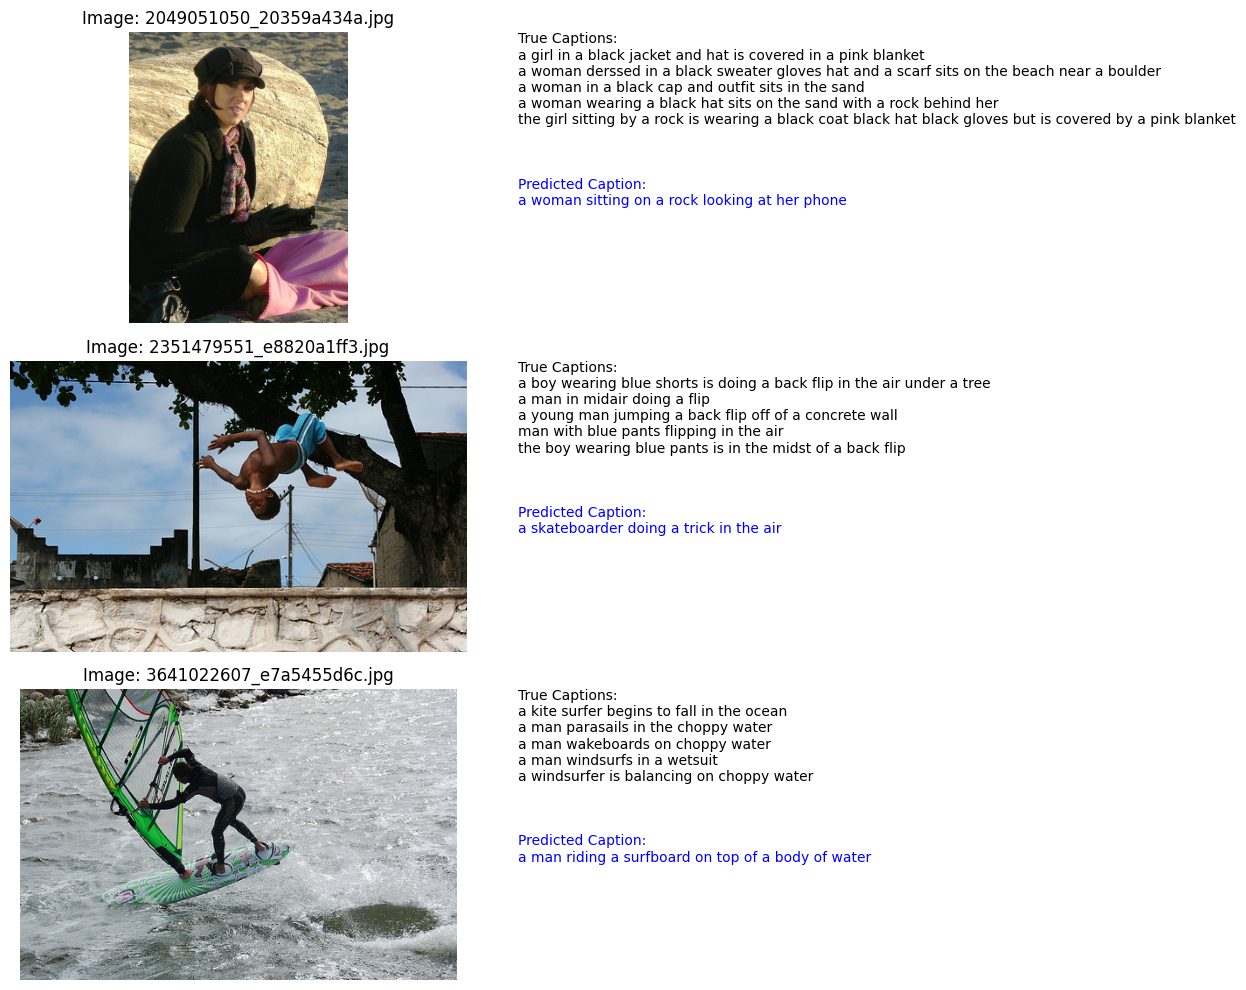


--- Evaluation Metrics (ViT-GPT2 Pipeline) ---
BLEU-1 Score: 0.6083
BLEU-4 Score: 0.1738


In [16]:
# --- 6. Quick Validation Evaluation via BLEU Metric ---
print("\n--- Evaluating System Quality on Validation Split via BLEU ---")
val_dataset = FlickrHfDataset(val_images_set)
# Using a batch size of 32 to process 100 images almost instantaneously
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

references = []
hypotheses = []

eval_sample_limit = 100
count = 0

for pixel_values, img_names in val_loader:
    if count >= eval_sample_limit:
        break

    # Generate predictions via Beam Search
    preds = generate_captions_batch(model, pixel_values, beam_width=3)

    for i, img_name in enumerate(img_names):
        references.append(all_captions[img_name])
        hypotheses.append(preds[i])

    count += len(img_names)

# Compute BLEU Scores
smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(references[:eval_sample_limit], hypotheses[:eval_sample_limit], weights=(1.0, 0, 0, 0), smoothing_function=smooth)
bleu4 = corpus_bleu(references[:eval_sample_limit], hypotheses[:eval_sample_limit], weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

import matplotlib.pyplot as plt

# --- 7. Sample Test Predictions (Verifying Correctness) ---
print("\n--- Generating Accurate Sample Inferences From Test Split ---")
test_dataset = FlickrHfDataset(test_images_set)

# Create a DataLoader for the test set with a small batch size
sample_test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

num_samples_to_show = 3
samples_shown = 0

plt.figure(figsize=(15, 10))

for pixel_values, img_names in sample_test_loader:
    if samples_shown >= num_samples_to_show:
        break

    img_name = img_names[0]

    # Get the image path
    img_path = os.path.join("Flicker8k_Dataset", img_name)
    image = Image.open(img_path).convert("RGB")

    # Get true captions
    true_captions = all_captions[img_name]
    true_captions_str = [" ".join(c) for c in true_captions]

    # Generate predicted caption
    predicted_caption = generate_captions_batch(model, pixel_values, beam_width=3)[0]
    predicted_caption_str = " ".join(predicted_caption)

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 1)
    plt.imshow(image)
    plt.title(f"Image: {img_name}")
    plt.axis('off')

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 2)
    plt.text(0, 1, f"True Captions:\n" + "\n".join(true_captions_str), fontsize=10, verticalalignment='top', wrap=True)
    plt.text(0, 0.5, f"Predicted Caption:\n{predicted_caption_str}", fontsize=10, verticalalignment='top', color='blue', wrap=True)
    plt.axis('off')

    samples_shown += 1

plt.tight_layout()
plt.show()

print(f"\n--- Evaluation Metrics (ViT-GPT2 Pipeline) ---")
print(f"BLEU-1 Score: {bleu1:.4f}")
print(f"BLEU-4 Score: {bleu4:.4f}")


test_loader = DataLoader(test_dataset, batch_size=3, shuffle=True)

### Visualize Sample Test Images with True and Predicted Captions

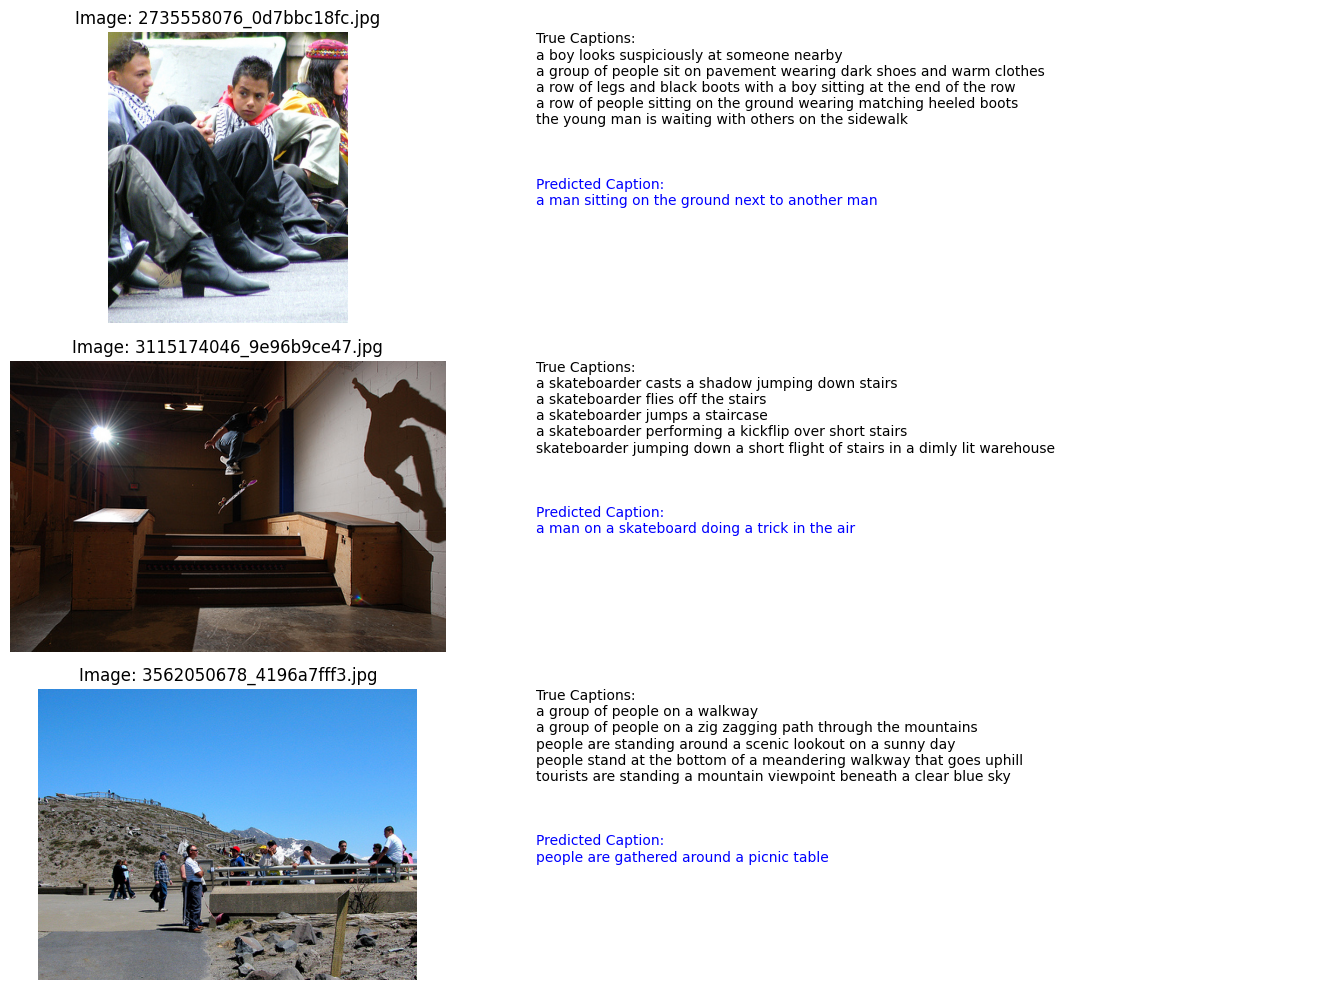

In [12]:
import matplotlib.pyplot as plt

# Create a DataLoader for the test set with a small batch size
sample_test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

num_samples_to_show = 3
samples_shown = 0

plt.figure(figsize=(15, 10))

for pixel_values, img_names in sample_test_loader:
    if samples_shown >= num_samples_to_show:
        break

    img_name = img_names[0]

    # Get the image path
    img_path = os.path.join("Flicker8k_Dataset", img_name)
    image = Image.open(img_path).convert("RGB")

    # Get true captions
    true_captions = all_captions[img_name]
    true_captions_str = [" ".join(c) for c in true_captions]

    # Generate predicted caption
    predicted_caption = generate_captions_batch(model, pixel_values, beam_width=3)[0]
    predicted_caption_str = " ".join(predicted_caption)

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 1)
    plt.imshow(image)
    plt.title(f"Image: {img_name}")
    plt.axis('off')

    plt.subplot(num_samples_to_show, 2, 2 * samples_shown + 2)
    plt.text(0, 1, f"True Captions:\n" + "\n".join(true_captions_str), fontsize=10, verticalalignment='top', wrap=True)
    plt.text(0, 0.5, f"Predicted Caption:\n{predicted_caption_str}", fontsize=10, verticalalignment='top', color='blue', wrap=True)
    plt.axis('off')

    samples_shown += 1

plt.tight_layout()
plt.show()